# Laboratorium 3 — Wizualizacja danych (Matplotlib, Plotly, plotnine)

**Zbiór danych:** *Gapminder* (wbudowany w `plotly.express`) — dane o krajach świata w latach 1952–2007:
- `country`, `continent`, `iso_alpha`, `iso_num` — identyfikatory geograficzne,
- `year` — szereg czasowy (1952–2007, co 5 lat),
- `lifeExp` — średnia długość życia,
- `pop` — populacja,
- `gdpPercap` — PKB per capita.

Zbiór został wybrany świadomie — łączy szereg czasowy, zmienne kategoryczne, kilka cech liczbowych i kody ISO krajów, dzięki czemu można na nim wykonać **wszystkie** typy wykresów z instrukcji laboratorium (w tym mapy geoprzestrzenne).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from mpl_toolkits.mplot3d import Axes3D

# Wczytanie zbioru danych Gapminder
df = px.data.gapminder()
df.head()


,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4


In [2]:
print("Wymiary zbioru:", df.shape)
print("Lata:", sorted(df['year'].unique()))
print("Kontynenty:", df['continent'].unique())
df.describe()


Wymiary zbioru: (1704, 8)
Lata: [np.int64(1952), np.int64(1957), np.int64(1962), np.int64(1967), np.int64(1972), np.int64(1977), np.int64(1982), np.int64(1987), np.int64(1992), np.int64(1997), np.int64(2002), np.int64(2007)]
Kontynenty: <StringArray>
['Asia', 'Europe', 'Africa', 'Americas', 'Oceania']
Length: 5, dtype: str


,year,lifeExp,pop,gdpPercap,iso_num
count,1704.00000,1704.000000,1.704000e+03,1704.000000,1704.000000
mean,1979.50000,59.474439,2.960121e+07,7215.327081,425.880282
std,17.26533,12.917107,1.061579e+08,9857.454543,248.305709
min,1952.00000,23.599000,6.001100e+04,241.165876,4.000000
25%,1965.75000,48.198000,2.793664e+06,1202.060309,208.000000
50%,1979.50000,60.712500,7.023596e+06,3531.846989,410.000000
75%,1993.25000,70.845500,1.958522e+07,9325.462346,638.000000
max,2007.00000,82.603000,1.318683e+09,113523.132900,894.000000


# 1. Wizualizacja w bibliotece Matplotlib

## 1.1 Wykres liniowy — średnia długość życia w Polsce w latach 1952–2007

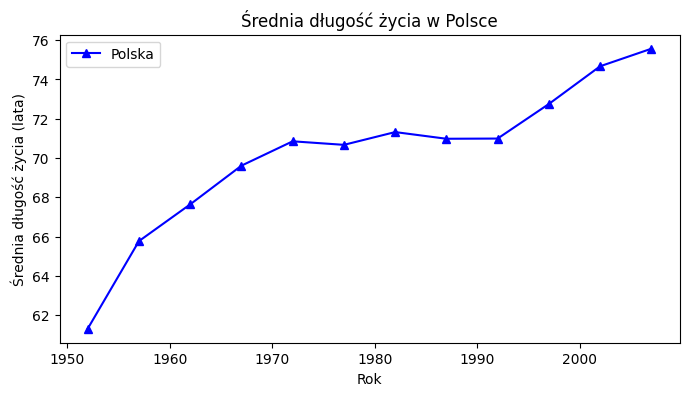

In [3]:
pl = df[df['country'] == 'Poland']

plt.figure(figsize=(8, 4))
plt.plot(pl['year'], pl['lifeExp'], marker='^', linestyle='-', color='b', label='Polska')
plt.xlabel("Rok")
plt.ylabel("Średnia długość życia (lata)")
plt.title("Średnia długość życia w Polsce")
plt.legend()
plt.show()


## 1.2 Wykres słupkowy — 10 najludniejszych krajów w 2007 roku

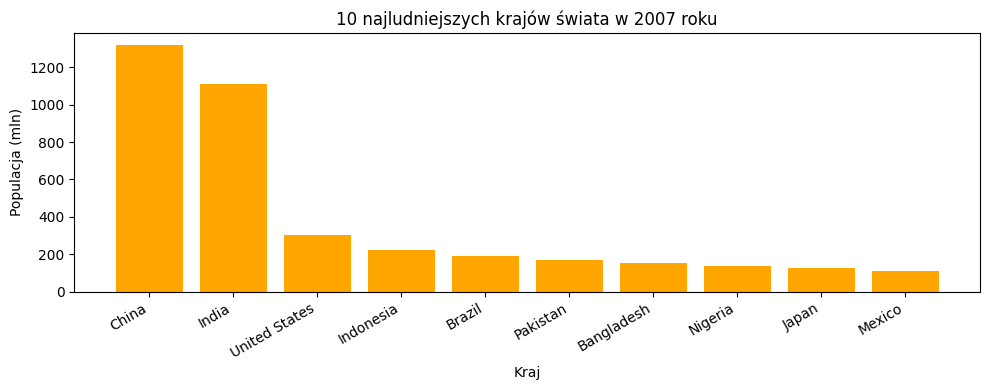

In [4]:
top10 = df[df['year'] == 2007].nlargest(10, 'pop')

plt.figure(figsize=(10, 4))
plt.bar(top10['country'], top10['pop'] / 1e6, color='orange')
plt.xlabel("Kraj")
plt.ylabel("Populacja (mln)")
plt.title("10 najludniejszych krajów świata w 2007 roku")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


## 1.3 Histogram — rozkład średniej długości życia w 2007 roku

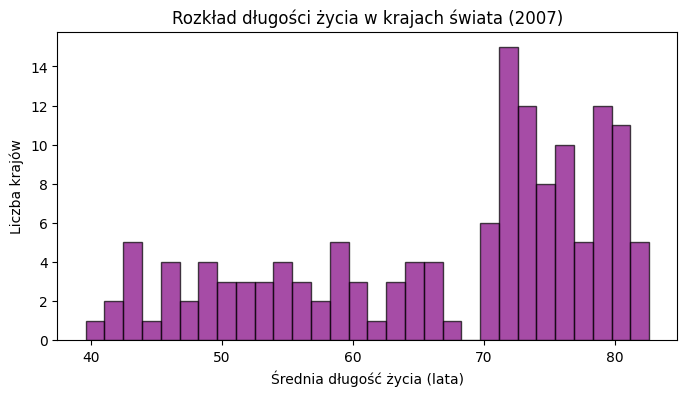

In [5]:
dane_2007 = df[df['year'] == 2007]['lifeExp']

plt.figure(figsize=(8, 4))
plt.hist(dane_2007, bins=30, color='purple', alpha=0.7, edgecolor='black')
plt.xlabel("Średnia długość życia (lata)")
plt.ylabel("Liczba krajów")
plt.title("Rozkład długości życia w krajach świata (2007)")
plt.show()


## 1.4 Wykres kołowy — udział populacji świata wg kontynentów (2007)

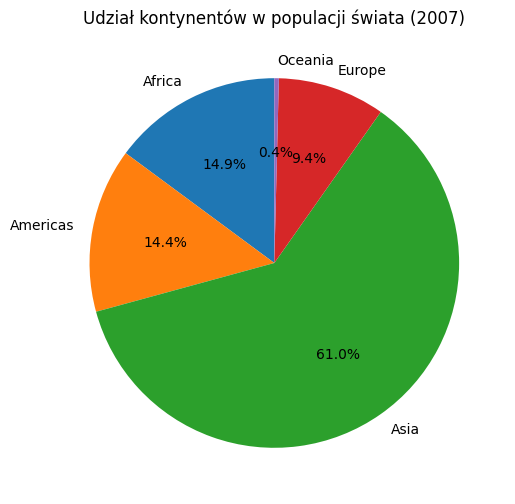

In [6]:
pop_kont = df[df['year'] == 2007].groupby('continent')['pop'].sum()

plt.figure(figsize=(6, 6))
plt.pie(pop_kont.values, labels=pop_kont.index, autopct='%1.1f%%', startangle=90)
plt.title("Udział kontynentów w populacji świata (2007)")
plt.show()


## 1.5 Kolory, linie i style markerów — porównanie 3 krajów

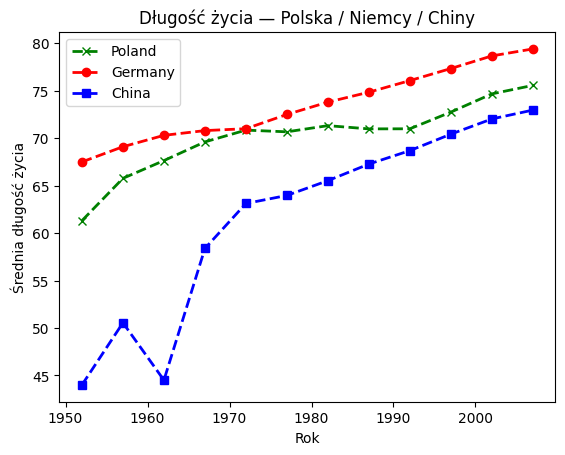

In [7]:
for kraj, kolor, marker in [('Poland', 'green', 'x'),
                            ('Germany', 'red', 'o'),
                            ('China', 'blue', 's')]:
    sub = df[df['country'] == kraj]
    plt.plot(sub['year'], sub['lifeExp'],
             color=kolor, marker=marker, linestyle='--', linewidth=2, label=kraj)

plt.xlabel("Rok")
plt.ylabel("Średnia długość życia")
plt.title("Długość życia — Polska / Niemcy / Chiny")
plt.legend()
plt.show()


## 1.6 Dodawanie siatki

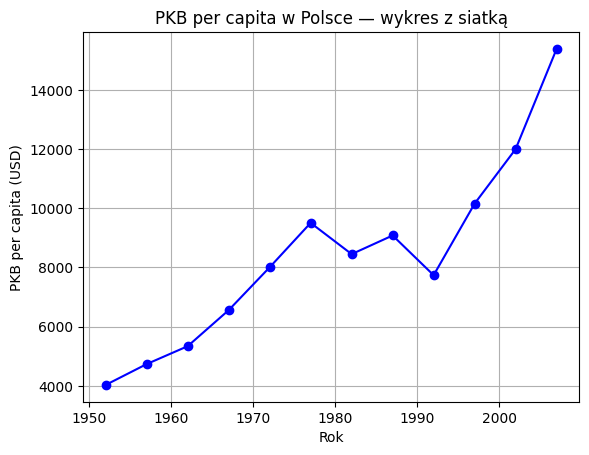

In [8]:
pl = df[df['country'] == 'Poland']

plt.plot(pl['year'], pl['gdpPercap'], color='blue', marker='o')
plt.grid(True)
plt.xlabel("Rok")
plt.ylabel("PKB per capita (USD)")
plt.title("PKB per capita w Polsce — wykres z siatką")
plt.show()


## 1.7 Adnotacje na wykresie

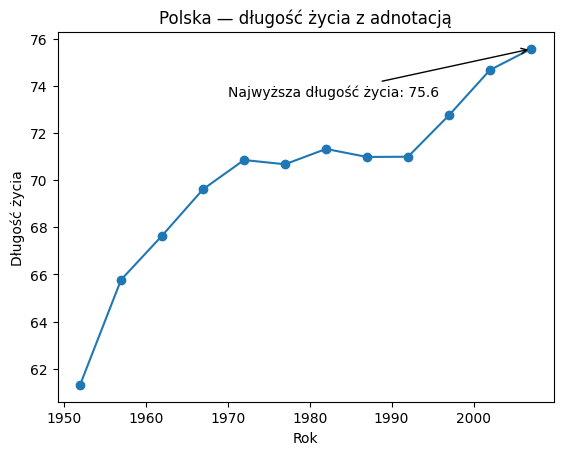

In [9]:
pl = df[df['country'] == 'Poland']
max_idx = pl['lifeExp'].idxmax()
xmax, ymax = pl.loc[max_idx, 'year'], pl.loc[max_idx, 'lifeExp']

plt.plot(pl['year'], pl['lifeExp'], marker='o')
plt.annotate(f'Najwyższa długość życia: {ymax:.1f}',
             xy=(xmax, ymax), xytext=(1970, ymax - 2),
             arrowprops=dict(facecolor='black', arrowstyle='->'))
plt.xlabel("Rok"); plt.ylabel("Długość życia")
plt.title("Polska — długość życia z adnotacją")
plt.show()


## 1.8 Wykres punktowy — PKB per capita vs długość życia (2007)

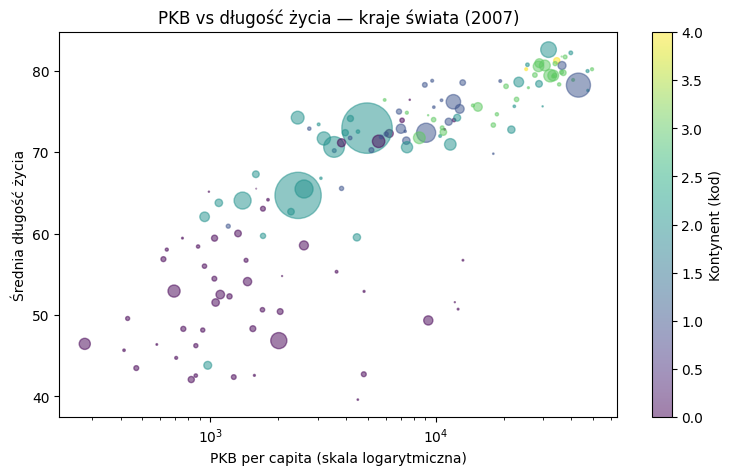

In [10]:
d2007 = df[df['year'] == 2007]

plt.figure(figsize=(9, 5))
plt.scatter(d2007['gdpPercap'], d2007['lifeExp'],
            s=d2007['pop'] / 1e6,           # wielkość bańki = populacja (mln)
            c=d2007['continent'].astype('category').cat.codes,
            alpha=0.5, cmap='viridis')
plt.colorbar(label='Kontynent (kod)')
plt.xscale('log')
plt.xlabel("PKB per capita (skala logarytmiczna)")
plt.ylabel("Średnia długość życia")
plt.title("PKB vs długość życia — kraje świata (2007)")
plt.show()


## 1.9 Wykres 3D — powierzchnia funkcji (przykład z instrukcji)

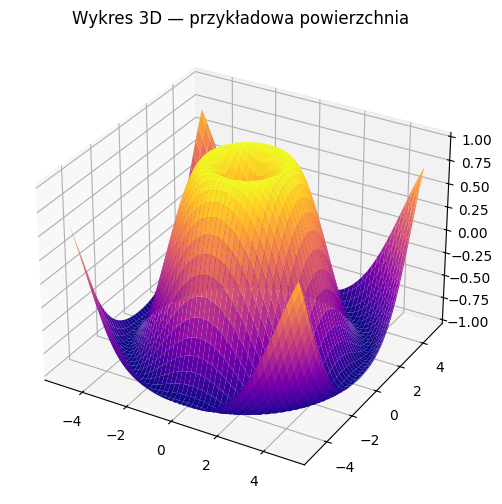

In [11]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z = np.sin(np.sqrt(X**2 + Y**2))

ax.plot_surface(X, Y, Z, cmap='plasma')
plt.title("Wykres 3D — przykładowa powierzchnia")
plt.show()


# 2. Wizualizacja w bibliotece Plotly

## 2.1 Wykres liniowy — długość życia w Polsce w czasie

In [12]:
pl = df[df['country'] == 'Poland']

fig = px.line(pl, x='year', y='lifeExp',
              title="Polska — średnia długość życia",
              labels={'year': 'Rok', 'lifeExp': 'Długość życia'},
              markers=True)
fig.show()


## 2.2 Wykres słupkowy — top 10 krajów wg populacji (2007)

In [13]:
top10 = df[df['year'] == 2007].nlargest(10, 'pop')

fig = px.bar(top10, x='country', y='pop', color='continent',
             title="10 najludniejszych krajów świata (2007)",
             labels={'country': 'Kraj', 'pop': 'Populacja', 'continent': 'Kontynent'})
fig.show()


## 2.3 Wykres kołowy — populacja świata wg kontynentów (2007)

In [14]:
pop_kont = df[df['year'] == 2007].groupby('continent', as_index=False)['pop'].sum()

fig = px.pie(pop_kont, names='continent', values='pop',
             title="Udział kontynentów w populacji świata (2007)")
fig.show()


## 2.4 Histogram — rozkład długości życia (2007)

In [15]:
d2007 = df[df['year'] == 2007]

fig = px.histogram(d2007, x='lifeExp', nbins=30, color='continent',
                   title="Rozkład długości życia (2007) wg kontynentu",
                   labels={'lifeExp': 'Długość życia', 'count': 'Liczba krajów'})
fig.show()


## 2.5 Dostosowywanie koloru i stylu linii

In [16]:
pl = df[df['country'] == 'Poland']

fig = px.line(pl, x='year', y='gdpPercap',
              title="Polska — PKB per capita (styl niestandardowy)")
fig.update_traces(line=dict(color='purple', width=4), mode='lines+markers')
fig.show()


## 2.6 Adnotacje

In [17]:
pl = df[df['country'] == 'Poland']

fig = px.line(pl, x='year', y='lifeExp',
              title="Polska — długość życia z adnotacją")
fig.add_annotation(x=1989, y=pl[pl['year'] == 1987]['lifeExp'].values[0],
                   text="Okres przemian", showarrow=True, arrowhead=2)
fig.show()


## 2.7 Wykres punktowy — PKB vs długość życia, rozmiar = populacja

In [18]:
d2007 = df[df['year'] == 2007]

fig = px.scatter(d2007, x='gdpPercap', y='lifeExp',
                 size='pop', color='continent',
                 hover_name='country', log_x=True, size_max=60,
                 title="PKB vs długość życia (2007)",
                 labels={'gdpPercap': 'PKB per capita (log)', 'lifeExp': 'Długość życia'})
fig.show()


## 2.8 Wykres 3D — powierzchnia (przykład z instrukcji)

In [19]:
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z = np.sin(np.sqrt(X**2 + Y**2))

fig = go.Figure(data=[go.Surface(z=Z, x=X, y=Y)])
fig.update_layout(title="Wykres 3D — powierzchnia",
                  scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z'))
fig.show()


## 2.9 Subploty — dwa kraje obok siebie

In [20]:
pl = df[df['country'] == 'Poland']
us = df[df['country'] == 'United States']

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=("Polska — długość życia", "USA — długość życia"))
fig.add_trace(go.Scatter(x=pl['year'], y=pl['lifeExp'],
                         mode='lines+markers', name='Polska'),
              row=1, col=1)
fig.add_trace(go.Scatter(x=us['year'], y=us['lifeExp'],
                         mode='lines+markers', name='USA'),
              row=1, col=2)
fig.update_layout(title="Porównanie długości życia (subploty)")
fig.show()


# 3. Wizualizacja w bibliotece plotnine

In [21]:
# !pip install plotnine

In [22]:
from plotnine import (ggplot, aes, geom_point, geom_line, geom_bar,
                       geom_histogram, geom_smooth, geom_boxplot, facet_wrap,
                       ggtitle, xlab, ylab, theme_minimal, scale_x_log10,
                       labs)


## 3.1 Wykres punktowy — PKB vs długość życia (2007)

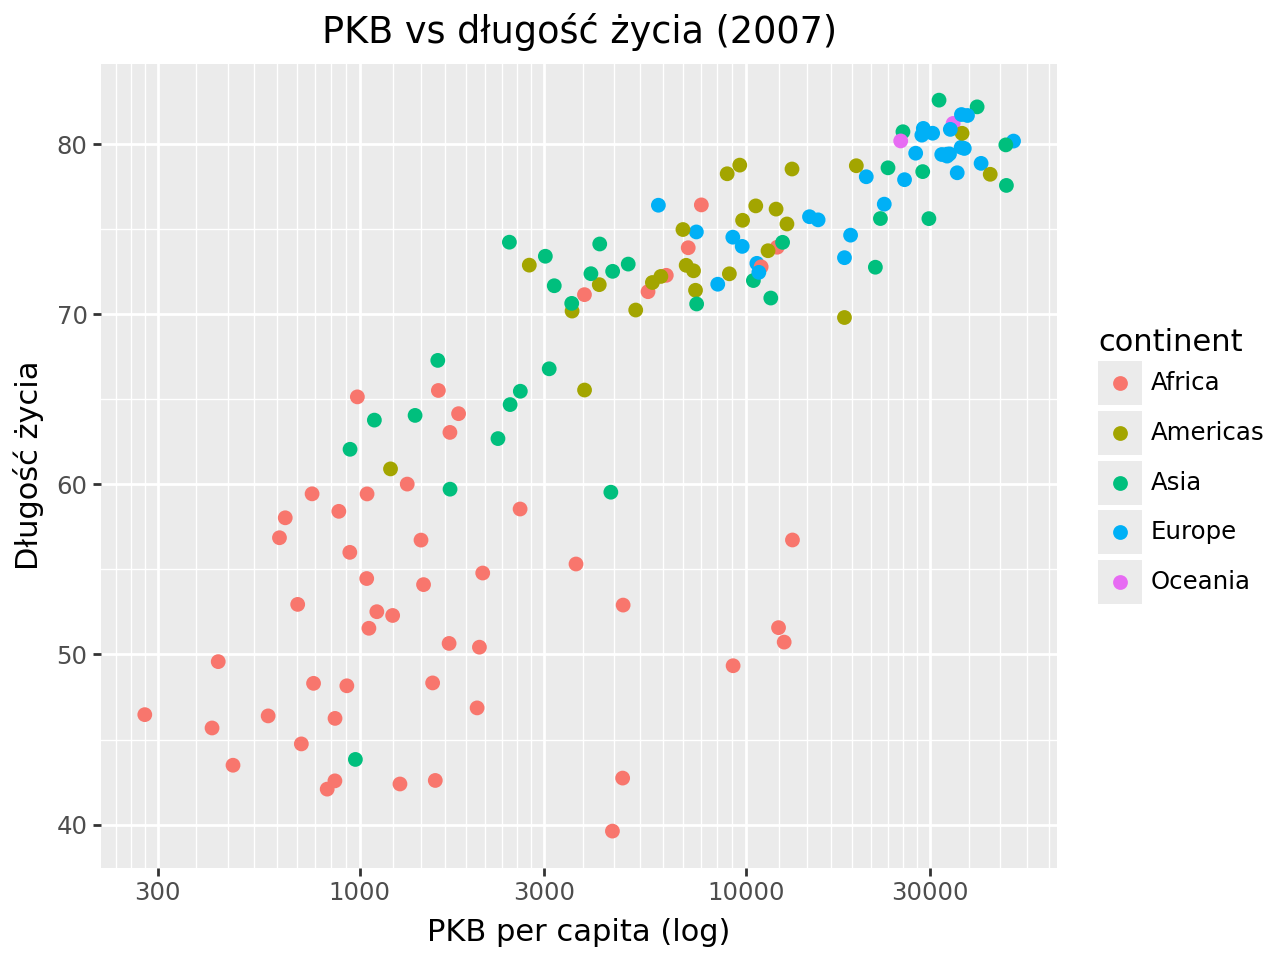

In [23]:
d2007 = df[df['year'] == 2007]

(ggplot(d2007) + aes(x='gdpPercap', y='lifeExp', color='continent') +
 geom_point(size=2) + scale_x_log10() +
 ggtitle("PKB vs długość życia (2007)") +
 xlab("PKB per capita (log)") + ylab("Długość życia"))


## 3.2 Wykres liniowy — długość życia w Polsce

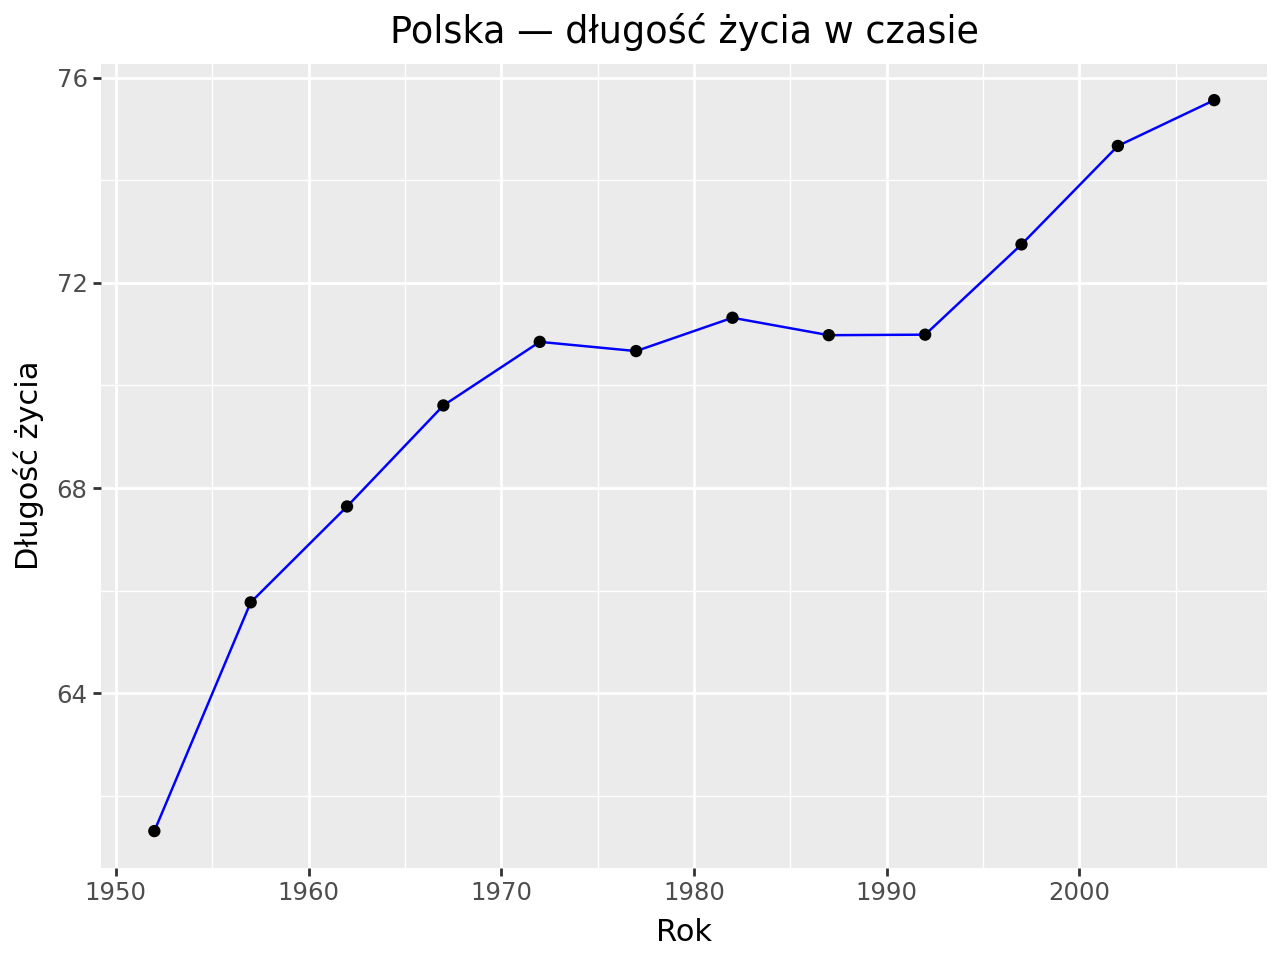

In [24]:
pl = df[df['country'] == 'Poland']

(ggplot(pl) + aes(x='year', y='lifeExp') +
 geom_line(color='blue') + geom_point() +
 ggtitle("Polska — długość życia w czasie") +
 xlab("Rok") + ylab("Długość życia"))


## 3.3 Wykres słupkowy — średnia długość życia wg kontynentu (2007)

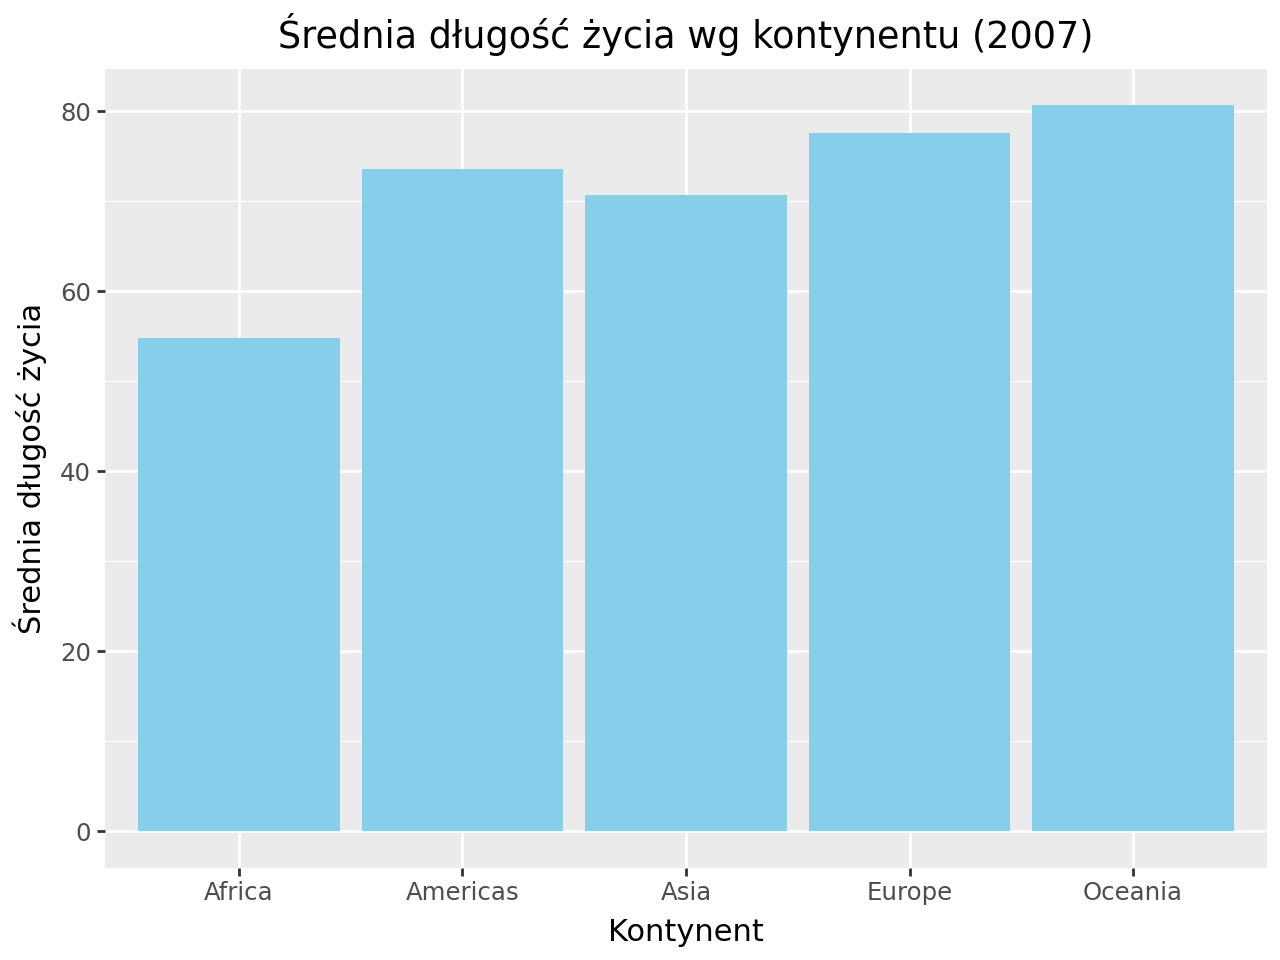

In [25]:
sr_kont = df[df['year'] == 2007].groupby('continent', as_index=False)['lifeExp'].mean()

(ggplot(sr_kont) + aes(x='continent', y='lifeExp') +
 geom_bar(stat='identity', fill='skyblue') +
 ggtitle("Średnia długość życia wg kontynentu (2007)") +
 xlab("Kontynent") + ylab("Średnia długość życia"))


## 3.4 Histogram — rozkład długości życia (2007)

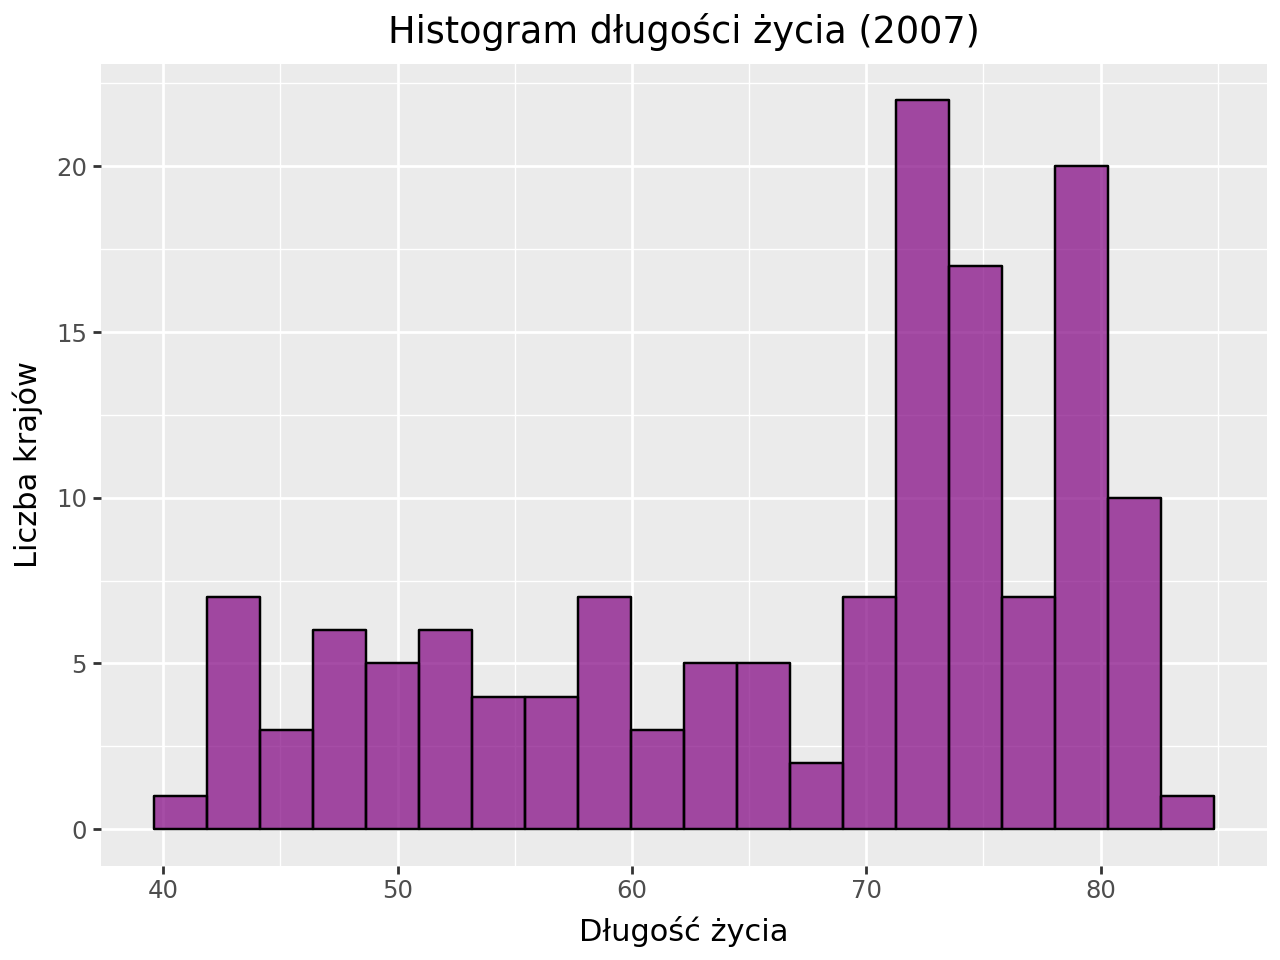

In [26]:
d2007 = df[df['year'] == 2007]

(ggplot(d2007) + aes(x='lifeExp') +
 geom_histogram(bins=20, fill='purple', alpha=0.7, color='black') +
 ggtitle("Histogram długości życia (2007)") +
 xlab("Długość życia") + ylab("Liczba krajów"))


## 3.5 Dostosowane kolory — punkty pokolorowane wg kontynentu

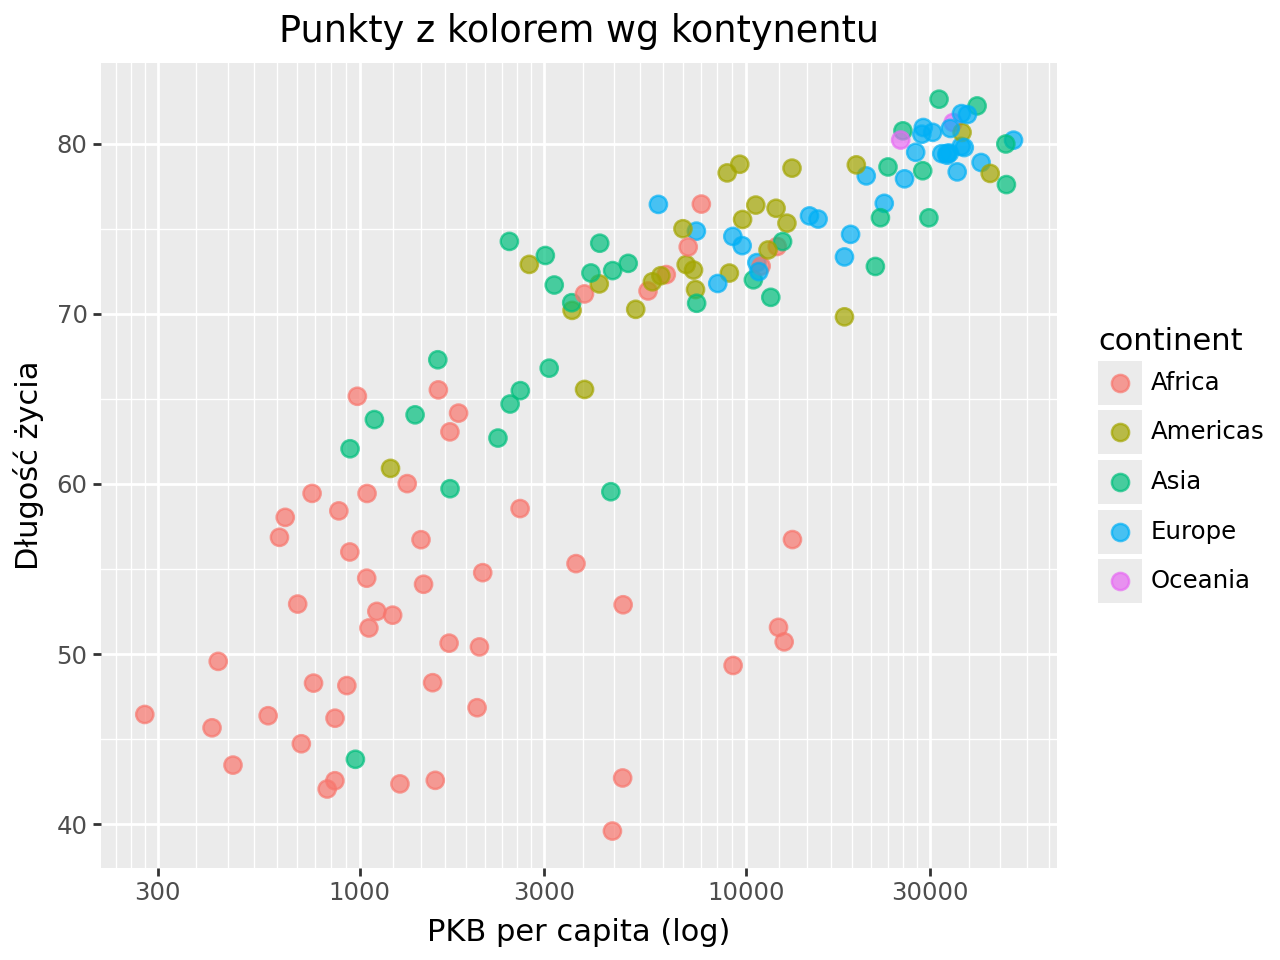

In [27]:
(ggplot(d2007) + aes(x='gdpPercap', y='lifeExp', color='continent') +
 geom_point(size=3, alpha=0.7) + scale_x_log10() +
 ggtitle("Punkty z kolorem wg kontynentu") +
 xlab("PKB per capita (log)") + ylab("Długość życia"))


## 3.6 Linia trendu — regresja PKB vs długość życia

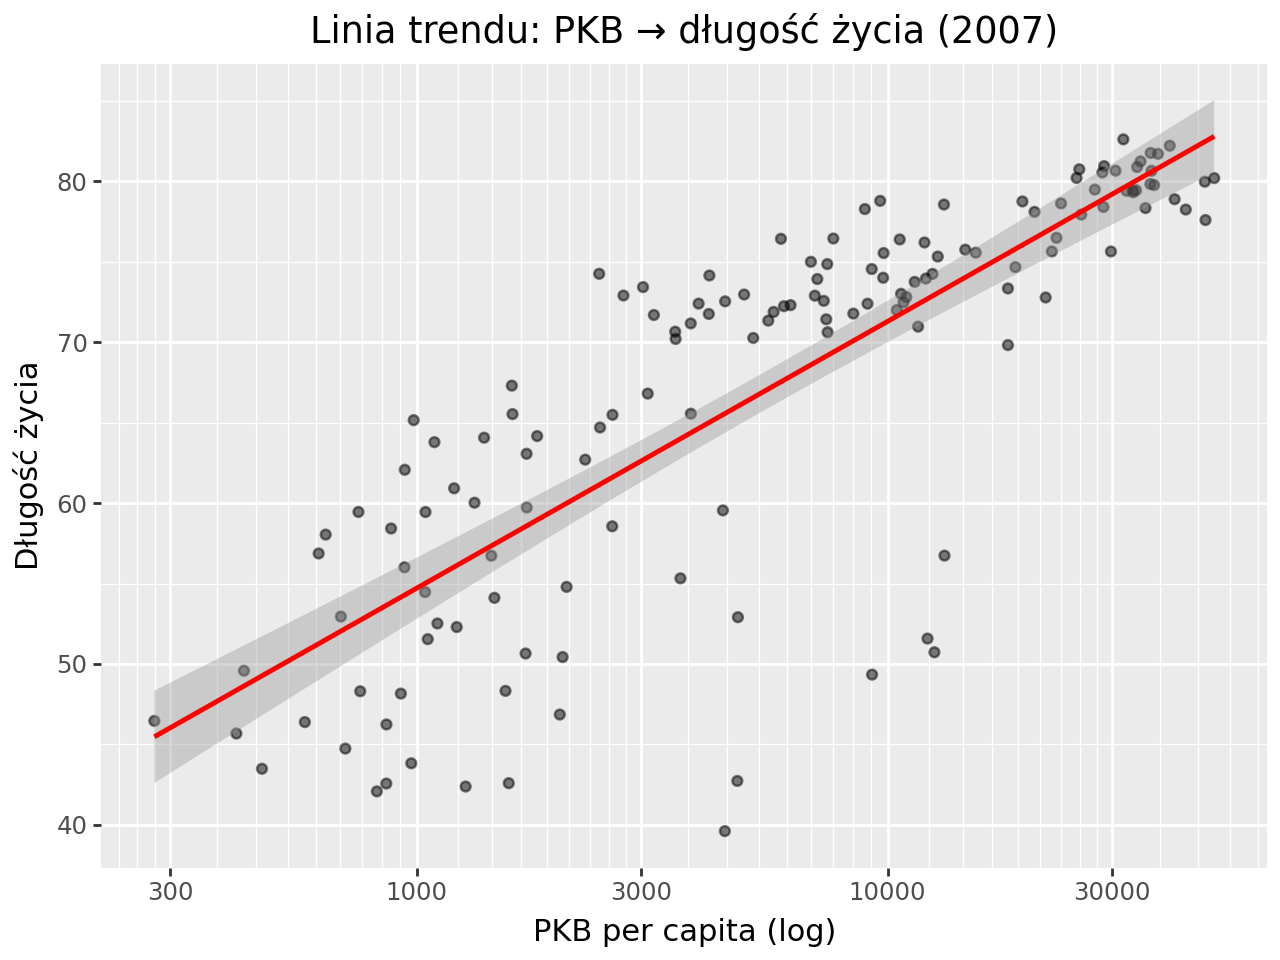

In [28]:
(ggplot(d2007) + aes(x='gdpPercap', y='lifeExp') +
 geom_point(alpha=0.5) + geom_smooth(method='lm', color='red') + scale_x_log10() +
 ggtitle("Linia trendu: PKB → długość życia (2007)") +
 xlab("PKB per capita (log)") + ylab("Długość życia"))


## 3.7 Facetowanie — osobny wykres dla każdego kontynentu

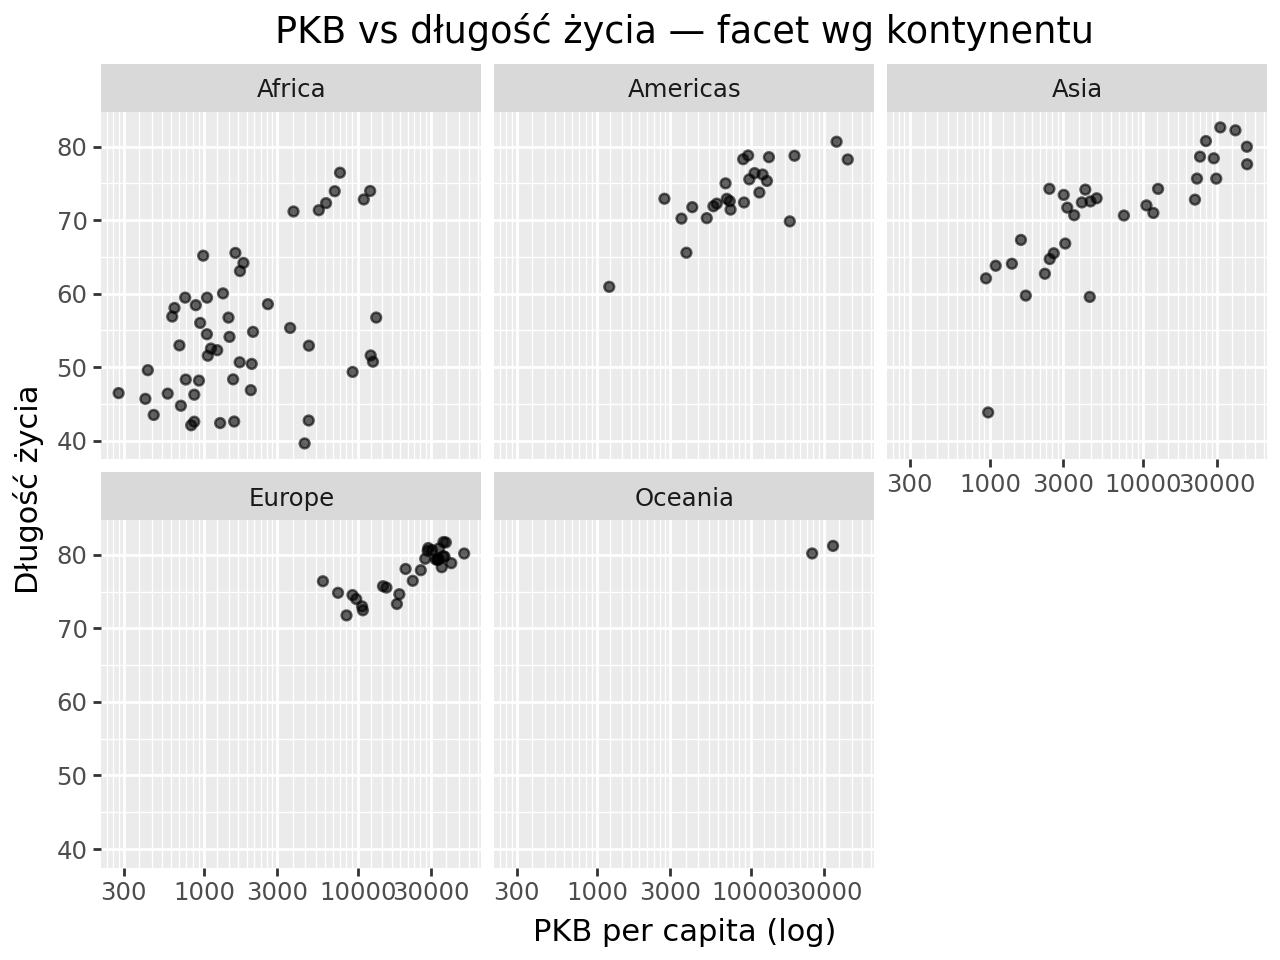

In [29]:
(ggplot(d2007) + aes(x='gdpPercap', y='lifeExp') +
 geom_point(alpha=0.6) + scale_x_log10() +
 facet_wrap('~continent') +
 ggtitle("PKB vs długość życia — facet wg kontynentu") +
 xlab("PKB per capita (log)") + ylab("Długość życia"))


## 3.8 Wykres pudełkowy — długość życia wg kontynentu

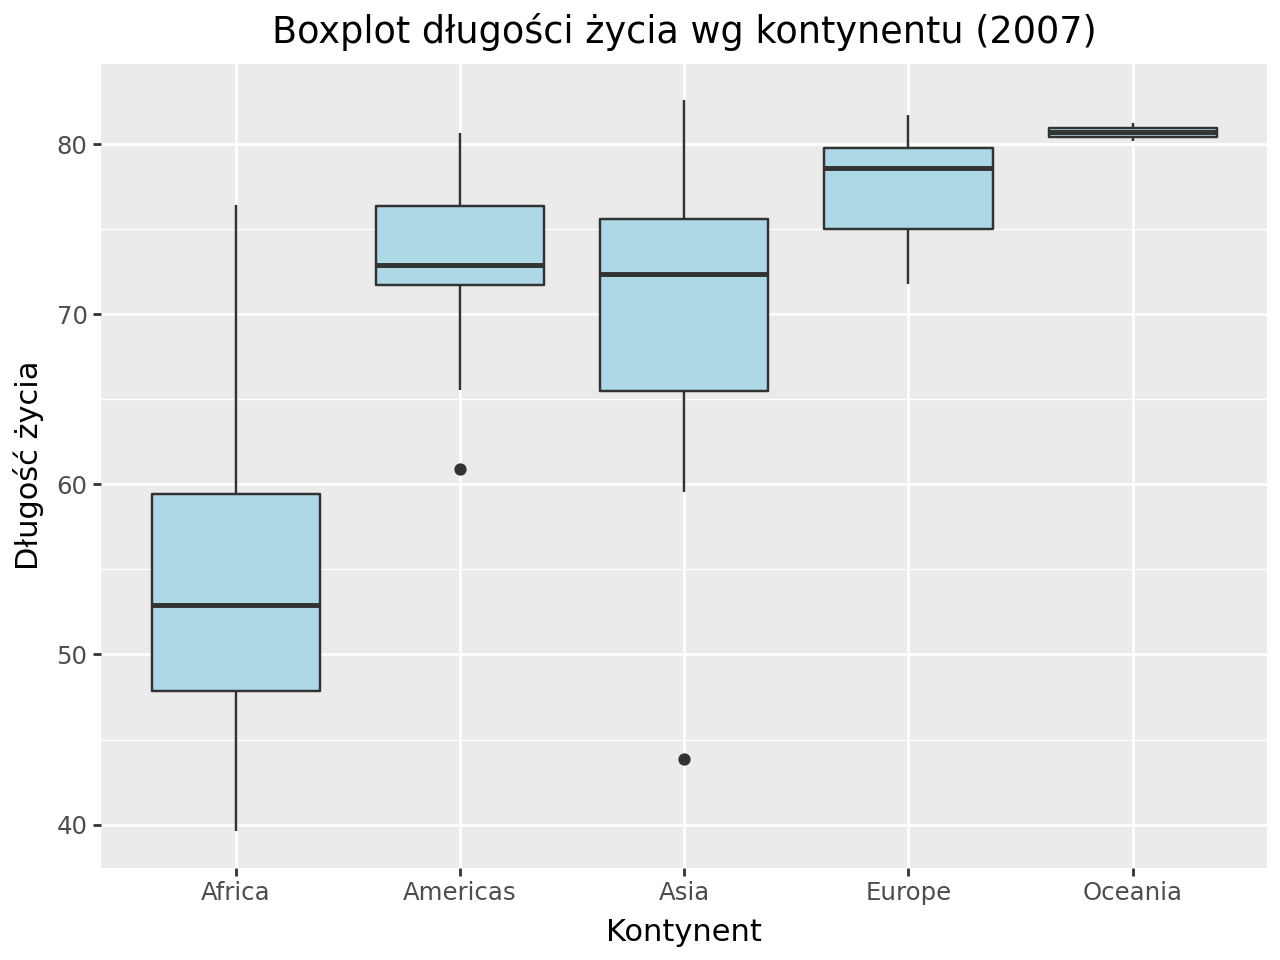

In [30]:
(ggplot(d2007) + aes(x='continent', y='lifeExp') +
 geom_boxplot(fill='lightblue') +
 ggtitle("Boxplot długości życia wg kontynentu (2007)") +
 xlab("Kontynent") + ylab("Długość życia"))


## 3.9 Dodanie motywu — `theme_minimal`

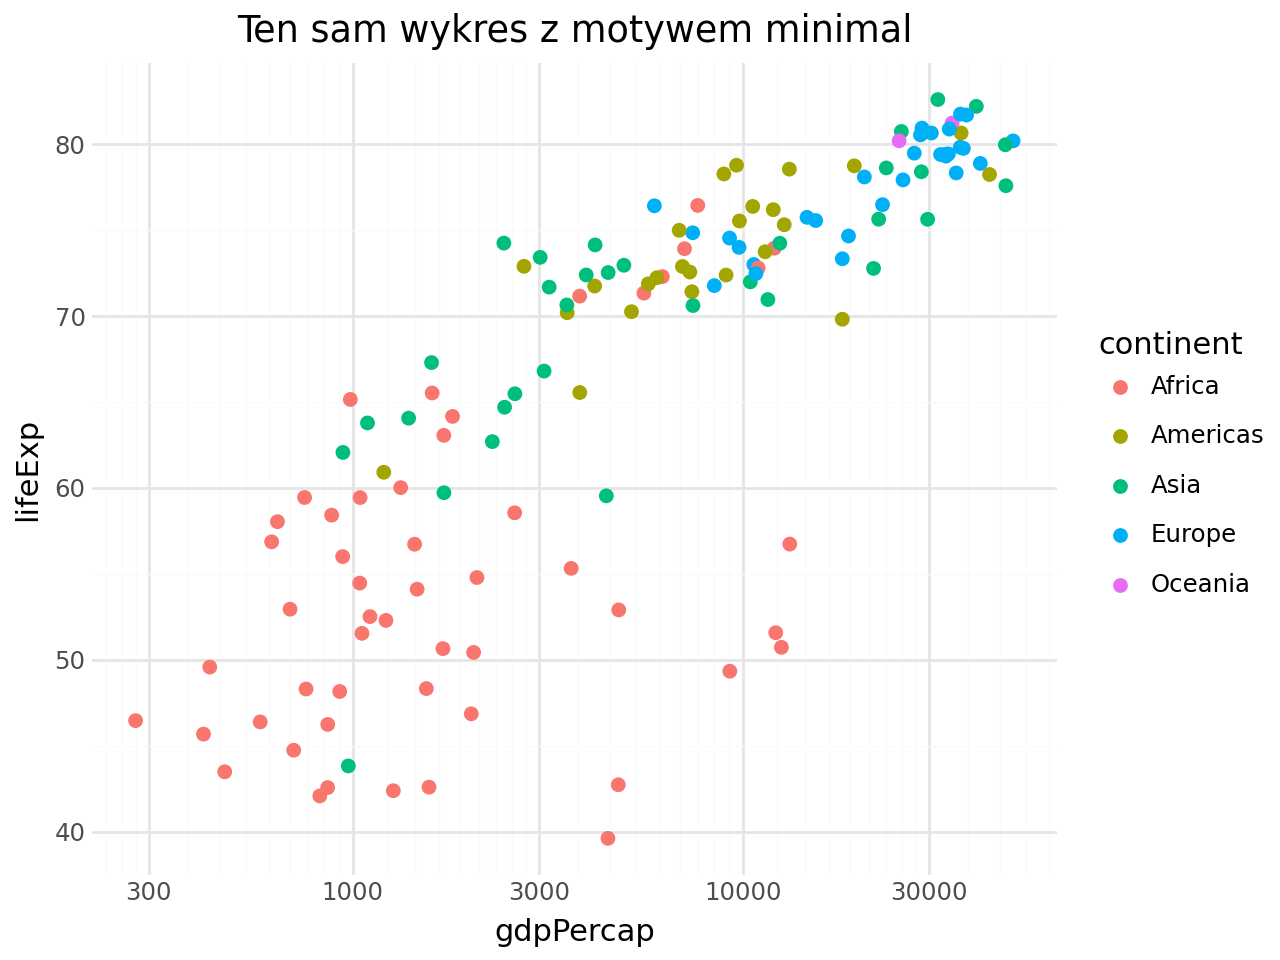

In [31]:
(ggplot(d2007) + aes(x='gdpPercap', y='lifeExp', color='continent') +
 geom_point(size=2) + scale_x_log10() +
 ggtitle("Ten sam wykres z motywem minimal") +
 theme_minimal())


# 4. Wizualizacja geoprzestrzenna (Plotly)

## 4.1 Mapa punktowa — wybrane stolice świata

In [32]:
stolice = pd.DataFrame({
    'miasto':   ['Warszawa', 'Berlin', 'Paryż', 'Londyn', 'Madryt', 'Rzym', 'Moskwa', 'Tokio', 'Pekin', 'Waszyngton'],
    'latitude': [52.2297, 52.5200, 48.8566, 51.5074, 40.4168, 41.9028, 55.7558, 35.6895, 39.9042, 38.9072],
    'longitude':[21.0122, 13.4050,  2.3522, -0.1278, -3.7038, 12.4964, 37.6173,139.6917,116.4074,-77.0369]
})

fig = px.scatter_map(stolice, lat='latitude', lon='longitude',
                     hover_name='miasto', zoom=1, height=500,
                     map_style='open-street-map',
                     title="Wybrane stolice świata")
fig.show()


## 4.2 Mapa choropleth — populacja krajów w 2007

In [33]:
d2007 = df[df['year'] == 2007]

fig = px.choropleth(d2007, locations='iso_alpha', color='pop',
                    hover_name='country',
                    color_continuous_scale='Viridis',
                    labels={'pop': 'Populacja'},
                    title="Populacja krajów świata (2007)")
fig.show()


## 4.3 Mapa choropleth — PKB per capita (2007, skala log)

In [34]:
d2007 = df[df['year'] == 2007].copy()
d2007['log_gdp'] = np.log10(d2007['gdpPercap'])

fig = px.choropleth(d2007, locations='iso_alpha', color='log_gdp',
                    hover_name='country',
                    color_continuous_scale='Plasma',
                    labels={'log_gdp': 'log10(PKB per capita)'},
                    title="PKB per capita na świecie (2007, skala log)")
fig.show()


## 4.4 Mapa cieplna (Densitymap) — przykładowe punkty wokół Warszawy

In [35]:
np.random.seed(0)
lats = np.random.normal(52.2297, 0.05, 500)
lons = np.random.normal(21.0122, 0.05, 500)
wagi = np.random.uniform(1, 10, 500)

fig = go.Figure(go.Densitymap(
    lat=lats, lon=lons, z=wagi, radius=20, colorscale='Hot'))
fig.update_layout(
    map_style='open-street-map',
    map_center_lon=21.0122, map_center_lat=52.2297, map_zoom=9,
    title="Gęstość punktów wokół Warszawy")
fig.show()


## 4.5 Mapa stanów USA — przykładowa populacja

In [36]:
df_usa = pd.DataFrame({
    'State': ['CA', 'TX', 'FL', 'NY', 'PA', 'IL', 'OH', 'GA', 'NC', 'MI'],
    'Population': [39538223, 29145505, 21538187, 20201249, 13002700,
                   12812508, 11799448, 10711908, 10439388, 10077331]
})

fig = px.choropleth(df_usa, locations='State', locationmode='USA-states',
                    color='Population', color_continuous_scale='Viridis',
                    labels={'Population': 'Populacja'},
                    title="Populacja wybranych stanów USA")
fig.update_layout(geo_scope='usa')
fig.show()


# 5. Podsumowanie

W ramach laboratorium na zbiorze **Gapminder** zaprezentowano komplet typów wykresów z instrukcji:

**Matplotlib:** liniowy, słupkowy, histogram, kołowy, niestandardowe style, siatka, adnotacje, punktowy, 3D.

**Plotly:** liniowy, słupkowy, kołowy, histogram, dostosowanie stylu, adnotacje, punktowy (bubble chart), 3D, subploty.

**plotnine:** punktowy, liniowy, słupkowy, histogram, dostosowane kolory, linia trendu (regresja liniowa), facetowanie, boxplot, motyw `theme_minimal`.

**Mapy (Plotly):** punktowa (stolice), choropleth populacji, choropleth PKB, mapa cieplna (Densitymap), mapa stanów USA.

Dzięki bogactwu zbioru (wymiar czasowy, kategorie, kody ISO, kilka cech liczbowych) wszystkie wykresy mają sensowną interpretację merytoryczną, a nie są jedynie odtworzeniem składni z instrukcji.